<center><img src="redpopcorn.jpg"></center>

**Netflix**! What started in 1997 as a DVD rental service has since exploded into one of the largest entertainment and media companies.

Given the large number of movies and series available on the platform, it is a perfect opportunity to flex your exploratory data analysis skills and dive into the entertainment industry.

You work for a production company that specializes in nostalgic styles. You want to do some research on movies released in the 1990's. You'll delve into Netflix data and perform exploratory data analysis to better understand this awesome movie decade!

You have been supplied with the dataset `netflix_data.csv`, along with the following table detailing the column names and descriptions. Feel free to experiment further after submitting!

## The data
### **netflix_data.csv**
| Column | Description |
|--------|-------------|
| `show_id` | The ID of the show |
| `type` | Type of show |
| `title` | Title of the show |
| `director` | Director of the show |
| `cast` | Cast of the show |
| `country` | Country of origin |
| `date_added` | Date added to Netflix |
| `release_year` | Year of Netflix release |
| `duration` | Duration of the show in minutes |
| `description` | Description of the show |
| `genre` | Show genre |

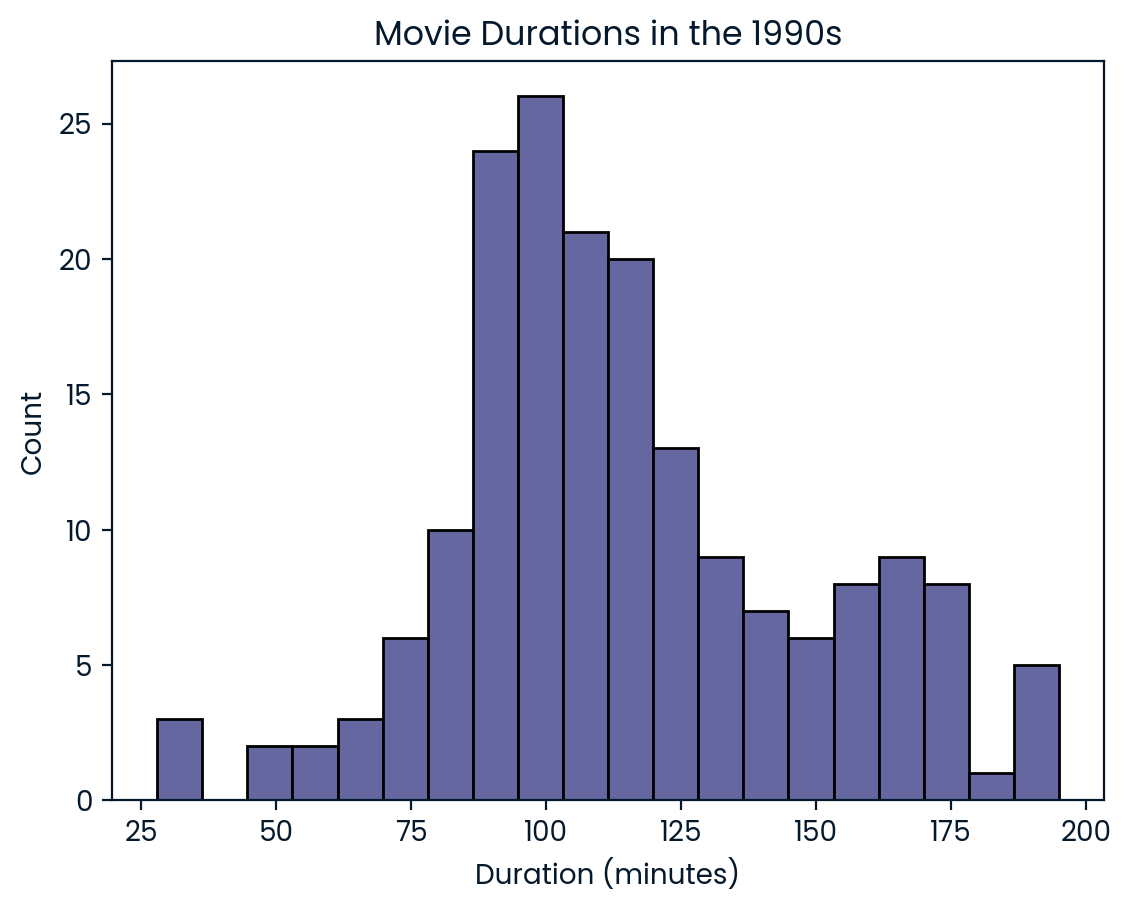

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 0: Load the data
netflix_df = pd.read_csv("netflix_data.csv")

# Step 1: Filter for movies released in the 1990s
movies_90s = netflix_df[
    (netflix_df['type'] == 'Movie') &
    (netflix_df['release_year'] >= 1990) &
    (netflix_df['release_year'] <= 1999)
]

# Clean and convert duration column
# Ensure the 'duration' column is treated as string before extracting numbers
movies_90s['duration'] = movies_90s['duration'].astype(str).str.extract('(\d+)').astype(int)

# Save to required variable
duration = movies_90s['duration'].mode()[0]

# Step 2: Plot distribution (optional for visualization)
plt.hist(movies_90s['duration'], bins=20, edgecolor='black')
plt.title('Movie Durations in the 1990s')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.show()

# Step 3: Count short action movies (< 90 minutes)
action_movies = movies_90s[movies_90s['genre'].str.contains('Action', case=False, na=False)]
short_movie_count = (action_movies['duration'] < 90).sum()